<a href="https://colab.research.google.com/github/bhargavi-chinnu/Federated-Learning-Based-IDS/blob/main/FL_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow numpy pandas scikit-learn matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving network_security_dataset.csv to network_security_dataset.csv


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Packet_Size,Transmission_Rate,Latency,Protocol_Type,Active_Connections,CPU_Usage,Memory_Usage,Bandwidth_Utilization,Request_Response_Time,Auth_Failures,...,IDS_Alerts,Anomalous_Load,DWT_Feature_1,DWT_Feature_2,DWT_Feature_3,DWT_Feature_4,DWT_Feature_5,DWT_Feature_6,DWT_Feature_7,DWT_Feature_8
0,602,189.384208,13.392765,1,481,43.735034,5763.534906,57.437973,0.142442,9,...,8,0,0.023823,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,935,110.765404,43.045266,1,455,43.911245,6448.478606,76.043970,1.185326,9,...,5,0,0.186256,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1360,185.916650,58.806998,0,196,6.386002,11960.841075,14.270273,1.083089,9,...,11,1,1.697022,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,770,98.224355,23.329072,0,284,19.795452,2231.916074,31.692037,1.410343,0,...,5,0,-0.877065,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,606,121.465548,77.168243,0,87,46.523659,5092.833893,84.893301,1.334662,5,...,10,0,0.104157,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nTarget label distribution:\n", df['Anomalous_Load'].value_counts())

Dataset shape: (5000, 22)

Columns:
 Index(['Packet_Size', 'Transmission_Rate', 'Latency', 'Protocol_Type',
       'Active_Connections', 'CPU_Usage', 'Memory_Usage',
       'Bandwidth_Utilization', 'Request_Response_Time', 'Auth_Failures',
       'Access_Violations', 'Firewall_Blocks', 'IDS_Alerts', 'Anomalous_Load',
       'DWT_Feature_1', 'DWT_Feature_2', 'DWT_Feature_3', 'DWT_Feature_4',
       'DWT_Feature_5', 'DWT_Feature_6', 'DWT_Feature_7', 'DWT_Feature_8'],
      dtype='object')

Target label distribution:
 Anomalous_Load
0    3646
1    1354
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['Anomalous_Load'])
y = df['Anomalous_Load']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (5000, 21)
Labels shape: (5000,)


In [ ]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)

Categorical columns: Index([], dtype='object')


In [ ]:
# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols)
print("Shape after encoding:", X.shape)

Shape after encoding: (5000, 21)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4000, 21)
Test shape: (1000, 21)


In [ ]:
X_train_mlp = X_train
X_test_mlp = X_test

In [ ]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("CNN input shape:", X_train_cnn.shape)


CNN input shape: (4000, 21, 1)


In [ ]:
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("LSTM input shape:", X_train_lstm.shape)

LSTM input shape: (4000, 21, 1)


In [ ]:
X_train_cnn_lstm = X_train_cnn
X_test_cnn_lstm = X_test_cnn

In [ ]:
X_train_ae = X_train
X_test_ae = X_test

In [ ]:
def create_federated_clients(X, y, num_clients=5):
    client_data = {}
    data_size = len(X)
    shard_size = data_size // num_clients

    indices = np.random.permutation(data_size)

    for i in range(num_clients):
        start = i * shard_size
        end = (i + 1) * shard_size if i != num_clients - 1 else data_size

        client_indices = indices[start:end]
        client_data[f'client_{i+1}'] = (
            X[client_indices],
            y.iloc[client_indices]
        )

    return client_data


In [ ]:
NUM_CLIENTS = 5

# MLP Clients
mlp_clients = create_federated_clients(X_train_mlp, y_train, NUM_CLIENTS)

# CNN Clients
cnn_clients = create_federated_clients(X_train_cnn, y_train, NUM_CLIENTS)

# LSTM Clients
lstm_clients = create_federated_clients(X_train_lstm, y_train, NUM_CLIENTS)

# CNN-LSTM Clients
cnn_lstm_clients = create_federated_clients(X_train_cnn_lstm, y_train, NUM_CLIENTS)

# Autoencoder Clients (no labels needed but kept for consistency)
ae_clients = create_federated_clients(X_train_ae, y_train, NUM_CLIENTS)

In [ ]:
for client, (X_c, y_c) in mlp_clients.items():
    print(client, "-> samples:", X_c.shape[0])

client_1 -> samples: 800
client_2 -> samples: 800
client_3 -> samples: 800
client_4 -> samples: 800
client_5 -> samples: 800


**MLP Model**

In [ ]:
def build_mlp(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
input_dim = X_train_mlp.shape[1]
global_mlp_model = build_mlp(input_dim)

global_mlp_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def local_train(model, X, y, epochs=2, batch_size=32):
    model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    return model.get_weights()


In [ ]:
def federated_average(weights_list):
    avg_weights = []

    for weights in zip(*weights_list):
        avg_weights.append(
            np.mean(np.array(weights), axis=0)
        )
    return avg_weights


In [ ]:
ROUNDS = 10
LOCAL_EPOCHS = 2

for round_num in range(ROUNDS):
    print(f"\n--- Federated Round {round_num+1} ---")

    local_weights = []

    for client, (X_client, y_client) in mlp_clients.items():
        # Create local model
        local_model = build_mlp(input_dim)
        local_model.set_weights(global_mlp_model.get_weights())

        # Local training
        weights = local_train(
            local_model,
            X_client,
            y_client,
            epochs=LOCAL_EPOCHS
        )

        local_weights.append(weights)

    # Aggregate weights
    new_global_weights = federated_average(local_weights)
    global_mlp_model.set_weights(new_global_weights)



--- Federated Round 1 ---

--- Federated Round 2 ---

--- Federated Round 3 ---

--- Federated Round 4 ---

--- Federated Round 5 ---

--- Federated Round 6 ---

--- Federated Round 7 ---

--- Federated Round 8 ---

--- Federated Round 9 ---

--- Federated Round 10 ---


In [ ]:
y_pred_prob = global_mlp_model.predict(X_test_mlp)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print("Federated MLP - Classification Report\n")
print(classification_report(y_test, y_pred))

Federated MLP - Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       729
           1       0.97      0.96      0.96       271

    accuracy                           0.98      1000
   macro avg       0.98      0.97      0.98      1000
weighted avg       0.98      0.98      0.98      1000



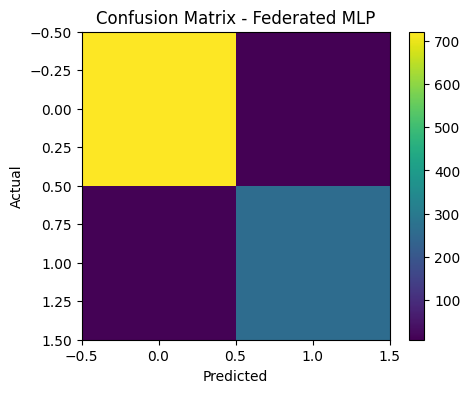

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - Federated MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
loss, accuracy = global_mlp_model.evaluate(X_test_mlp, y_test, verbose=0)
print(f"Federated MLP Test Accuracy: {accuracy:.4f}")

Federated MLP Test Accuracy: 0.9810


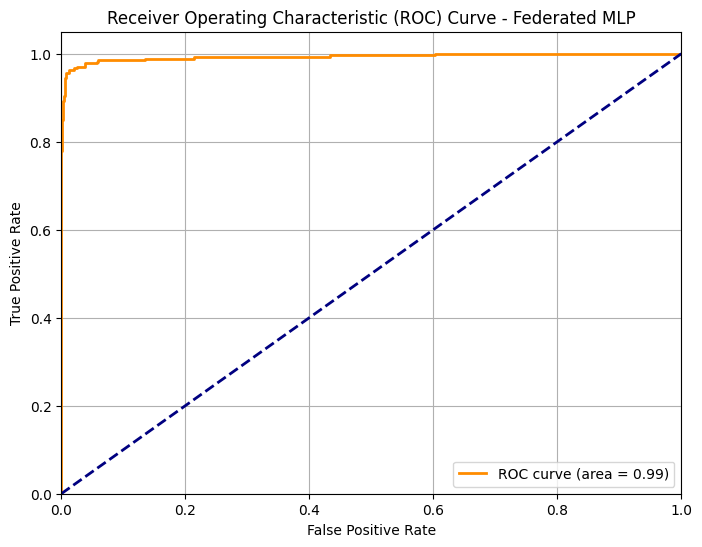

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Federated MLP')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**FL-BASED CNN INTRUSION DETECTION SYSTEM**

In [ ]:
def build_cnn(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
cnn_input_shape = X_train_cnn.shape[1:]  # (features, 1)

global_cnn_model = build_cnn(cnn_input_shape)
global_cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_153 (Dense)               │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_154 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,665 (194.00 KB)

 Trainable params: 49,665 (194.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def local_train_cnn(model, X, y, epochs=5, batch_size=32):
    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )
    return model.get_weights(), history


In [ ]:
ROUNDS = 5
LOCAL_EPOCHS = 5
for round_num in range(ROUNDS):
    print(f"\n==============================")
    print(f" Federated Round {round_num+1} (CNN)")
    print(f"==============================")

    local_weights = []

    for client, (X_client, y_client) in cnn_clients.items():
        print(f"\n🔹 Training on {client}")

        local_model = build_cnn(cnn_input_shape)
        local_model.set_weights(global_cnn_model.get_weights())

        weights, history = local_train_cnn(
            local_model,
            X_client,
            y_client,
            epochs=LOCAL_EPOCHS
        )

        local_weights.append(weights)

    # Federated Averaging
    new_global_weights = federated_average(local_weights)
    global_cnn_model.set_weights(new_global_weights)



 Federated Round 1 (CNN)

🔹 Training on client_1
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9864 - loss: 0.0543 - val_accuracy: 0.9875 - val_loss: 0.0436
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9746 - loss: 0.0669 - val_accuracy: 0.9937 - val_loss: 0.0399
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9872 - loss: 0.0470 - val_accuracy: 0.9812 - val_loss: 0.0695
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9919 - loss: 0.0345 - val_accuracy: 0.9750 - val_loss: 0.0859
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9881 - loss: 0.0474 - val_accuracy: 0.9812 - val_loss: 0.0419

🔹 Training on client_2
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9879 - loss: 0.0508 - val_accuracy: 0.9812 - val_loss: 0.0749
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9898 - loss: 0.0731 - val_accuracy: 0.9812 - val_loss: 0.0712
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

In [ ]:
y_pred_prob_cnn = global_cnn_model.predict(X_test_cnn)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
print("Federated CNN - Classification Report\n")
print(classification_report(y_test, y_pred_cnn))

Federated CNN - Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       729
           1       1.00      0.99      0.99       271

    accuracy                           0.99      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      0.99      0.99      1000



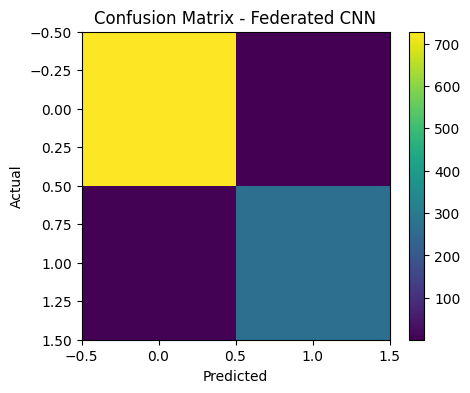

In [ ]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(5,4))
plt.imshow(cm_cnn)
plt.title("Confusion Matrix - Federated CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
loss_cnn, accuracy_cnn = global_cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Federated CNN Test Accuracy: {accuracy_cnn:.4f}")

Federated CNN Test Accuracy: 0.9950


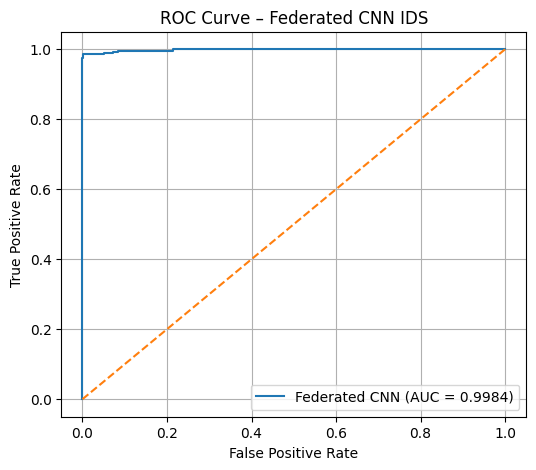

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Federated CNN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Federated CNN IDS")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**FL-BASED LSTM INTRUSION DETECTION SYSTEM**

In [ ]:
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
lstm_input_shape = X_train_lstm.shape[1:]
global_lstm_model = build_lstm(lstm_input_shape)
global_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_132"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_183 (Dropout)           │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_184 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_315 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def local_train_lstm(model, X, y, epochs=5, batch_size=32):
    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )
    return model.get_weights(), history

In [ ]:
ROUNDS = 5
LOCAL_EPOCHS = 5

for round_num in range(ROUNDS):
    print("\n==============================")
    print(f" Federated Round {round_num+1} (LSTM)")
    print("==============================")

    local_weights = []

    for client, (X_client, y_client) in lstm_clients.items():
        print(f"\n🔹 Training on {client}")

        # Initialize local model
        local_model = build_lstm(lstm_input_shape)
        local_model.set_weights(global_lstm_model.get_weights())

        # Local training
        weights, history = local_train_lstm(
            local_model,
            X_client,
            y_client,
            epochs=LOCAL_EPOCHS
        )

        local_weights.append(weights)
    new_global_weights = federated_average(local_weights)
    global_lstm_model.set_weights(new_global_weights)


 Federated Round 1 (LSTM)

🔹 Training on client_1
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7002 - loss: 0.6583 - val_accuracy: 0.7500 - val_loss: 0.5747
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7261 - loss: 0.5771 - val_accuracy: 0.7500 - val_loss: 0.5328
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7310 - loss: 0.5425 - val_accuracy: 0.7688 - val_loss: 0.5132
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7319 - loss: 0.5372 - val_accuracy: 0.7688 - val_loss: 0.5036
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7196 - loss: 0.5000 - val_accuracy: 0.7563 - val_loss: 0.5058

🔹 Training on client_2
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7012 - loss: 0.6660 - val_accuracy: 0.7188 - val_loss: 0.5706
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7598 - loss: 0.5317 - val_accuracy: 0.7000 - val_loss: 0.5530
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20m

In [ ]:
y_pred_prob_lstm = global_lstm_model.predict(X_test_lstm)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [ ]:
print("Federated LSTM - Classification Report\n")
print(classification_report(y_test, y_pred_lstm))

Federated LSTM - Classification Report

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       729
           1       0.61      0.38      0.47       271

    accuracy                           0.77      1000
   macro avg       0.70      0.64      0.66      1000
weighted avg       0.75      0.77      0.75      1000



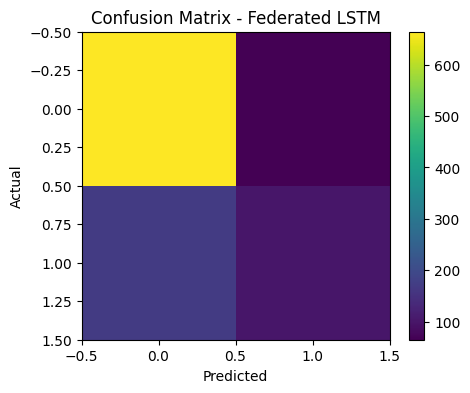

In [ ]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(5,4))
plt.imshow(cm_lstm)
plt.title("Confusion Matrix - Federated LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
y_prob_lstm = global_lstm_model.predict(X_test_lstm).ravel()

fpr_lstm, tpr_lstm, thresholds_lstm = roc_curve(y_test, y_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# Evaluate LSTM model and get accuracy
loss_lstm, accuracy_lstm = global_lstm_model.evaluate(X_test_lstm, y_test, verbose=0)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


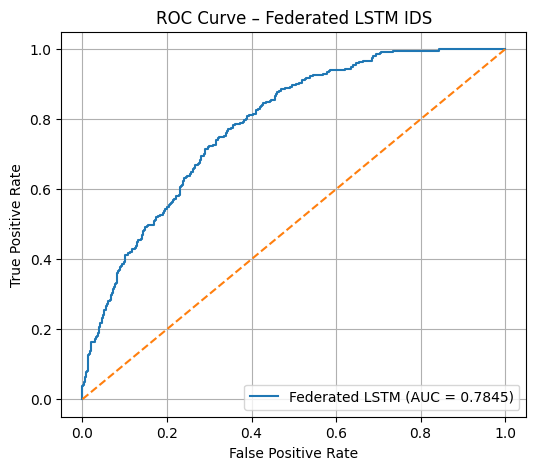

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr_lstm, tpr_lstm, label=f'Federated LSTM (AUC = {roc_auc_lstm:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Federated LSTM IDS")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**BUILD CNN-LSTM MODEL**

In [ ]:
def build_cnn_lstm(input_shape):
    model = Sequential([
        # CNN part
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
cnn_lstm_input_shape = X_train_cnn_lstm.shape[1:]
global_cnn_lstm_model = build_cnn_lstm(cnn_lstm_input_shape)
global_cnn_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_158"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_162 (Conv1D)             │ (None, 19, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_162               │ (None, 9, 64)          │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_163 (Conv1D)             │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_163               │ (None, 3, 128)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_235 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_341 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,433 (290.75 KB)

 Trainable params: 74,433 (290.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def local_train_cnn_lstm(model, X, y, epochs=5, batch_size=32):
    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )
    return model.get_weights(), history

In [ ]:
ROUNDS = 5
LOCAL_EPOCHS = 5

for round_num in range(ROUNDS):
    print("\n==============================")
    print(f" Federated Round {round_num+1} (CNN-LSTM)")
    print("==============================")

    local_weights = []

    for client, (X_client, y_client) in cnn_lstm_clients.items():
        print(f"\n🔹 Training on {client}")

        # Initialize local hybrid model
        local_model = build_cnn_lstm(cnn_lstm_input_shape)
        local_model.set_weights(global_cnn_lstm_model.get_weights())

        # Local training
        weights, history = local_train_cnn_lstm(
            local_model,
            X_client,
            y_client,
            epochs=LOCAL_EPOCHS
        )

        local_weights.append(weights)

    # Federated Averaging
    new_global_weights = federated_average(local_weights)
    global_cnn_lstm_model.set_weights(new_global_weights)



 Federated Round 1 (CNN-LSTM)

🔹 Training on client_1
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.6576 - loss: 0.6343 - val_accuracy: 0.6687 - val_loss: 0.6288
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7267 - loss: 0.5572 - val_accuracy: 0.6875 - val_loss: 0.5292
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7532 - loss: 0.4690 - val_accuracy: 0.8313 - val_loss: 0.3670
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8751 - loss: 0.3269 - val_accuracy: 0.9500 - val_loss: 0.1881
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9545 - loss: 0.1615 - val_accuracy: 0.9688 - val_loss: 0.1365

🔹 Training on client_2
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6506 - loss: 0.6322 - val_accuracy: 0.7500 - val_loss: 0.5340
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7407 - loss: 0.5411 - val_accuracy: 0.7688 - val_loss: 0.4545
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
y_pred_prob_cnn_lstm = global_cnn_lstm_model.predict(X_test_cnn_lstm)
y_pred_cnn_lstm = (y_pred_prob_cnn_lstm > 0.5).astype(int).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [ ]:
print("Federated CNN-LSTM - Classification Report\n")
print(classification_report(y_test, y_pred_cnn_lstm))

Federated CNN-LSTM - Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       729
           1       1.00      0.98      0.99       271

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



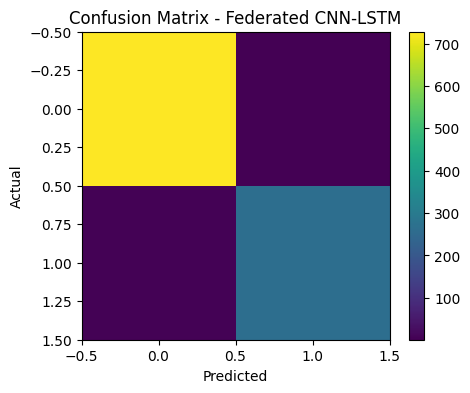

In [ ]:
cm_cnn_lstm = confusion_matrix(y_test, y_pred_cnn_lstm)

plt.figure(figsize=(5,4))
plt.imshow(cm_cnn_lstm)
plt.title("Confusion Matrix - Federated CNN-LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
loss_cnn_lstm, accuracy_cnn_lstm = global_cnn_lstm_model.evaluate(
    X_test_cnn_lstm, y_test, verbose=0
)

print(f"Federated CNN-LSTM Test Accuracy: {accuracy_cnn_lstm:.4f}")

Federated CNN-LSTM Test Accuracy: 0.9930


In [ ]:
y_prob_cnn_lstm = global_cnn_lstm_model.predict(X_test_cnn_lstm).ravel()

# ROC values
fpr_cnn_lstm, tpr_cnn_lstm, thresholds_cnn_lstm = roc_curve(y_test, y_prob_cnn_lstm)
roc_auc_cnn_lstm = auc(fpr_cnn_lstm, tpr_cnn_lstm)

print("CNN-LSTM AUC:", roc_auc_cnn_lstm)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CNN-LSTM AUC: 0.9920125127177198


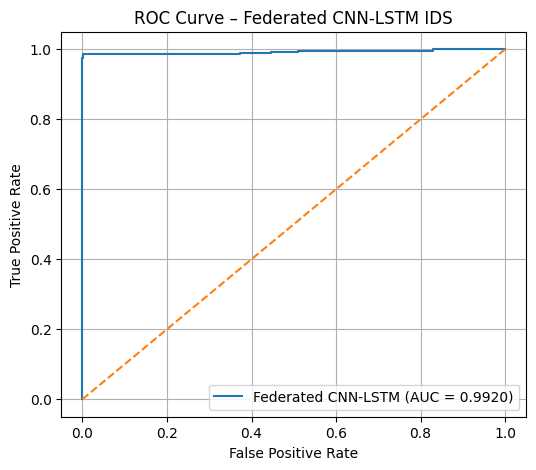

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(
    fpr_cnn_lstm,
    tpr_cnn_lstm,
    label=f'Federated CNN-LSTM (AUC = {roc_auc_cnn_lstm:.4f})'
)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Federated CNN-LSTM IDS")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

metrics = []

# MLP
metrics.append({
    "Model": "FL-MLP",
    "Accuracy": accuracy,
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_pred_prob)
})


In [ ]:
metrics.append({
    "Model": "FL-CNN",
    "Accuracy": accuracy_cnn,
    "Precision": precision_score(y_test, y_pred_cnn),
    "Recall": recall_score(y_test, y_pred_cnn),
    "F1-Score": f1_score(y_test, y_pred_cnn),
    "AUC": roc_auc
})


In [ ]:
metrics.append({
    "Model": "FL-LSTM",
    "Accuracy": accuracy_lstm,
    "Precision": precision_score(y_test, y_pred_lstm),
    "Recall": recall_score(y_test, y_pred_lstm),
    "F1-Score": f1_score(y_test, y_pred_lstm),
    "AUC": roc_auc_lstm
})

In [ ]:
metrics.append({
    "Model": "FL-CNN-LSTM",
    "Accuracy": accuracy_cnn_lstm,
    "Precision": precision_score(y_test, y_pred_cnn_lstm),
    "Recall": recall_score(y_test, y_pred_cnn_lstm),
    "F1-Score": f1_score(y_test, y_pred_cnn_lstm),
    "AUC": roc_auc_cnn_lstm
})

In [ ]:
comparison_df = pd.DataFrame(metrics)
comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,FL-MLP,0.981,0.9737,0.9557,0.9646,0.9933
1,FL-CNN,0.995,0.9963,0.9852,0.9907,0.9984
2,FL-LSTM,0.766,0.6108,0.3764,0.4658,0.7845
3,FL-CNN-LSTM,0.993,0.9962,0.9779,0.9870,0.9920


/tmp/ipython-input-2639961897.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=comparison_df, ax=axes[i], palette='viridis')
/tmp/ipython-input-2639961897.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=comparison_df, ax=axes[i], palette='viridis')
/tmp/ipython-input-2639961897.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=comparison_df, ax=axes[i], palette='viridis')
/tmp/ipython-input-2639961897.py:10: FutureWarning: 

Passing `palette` without as

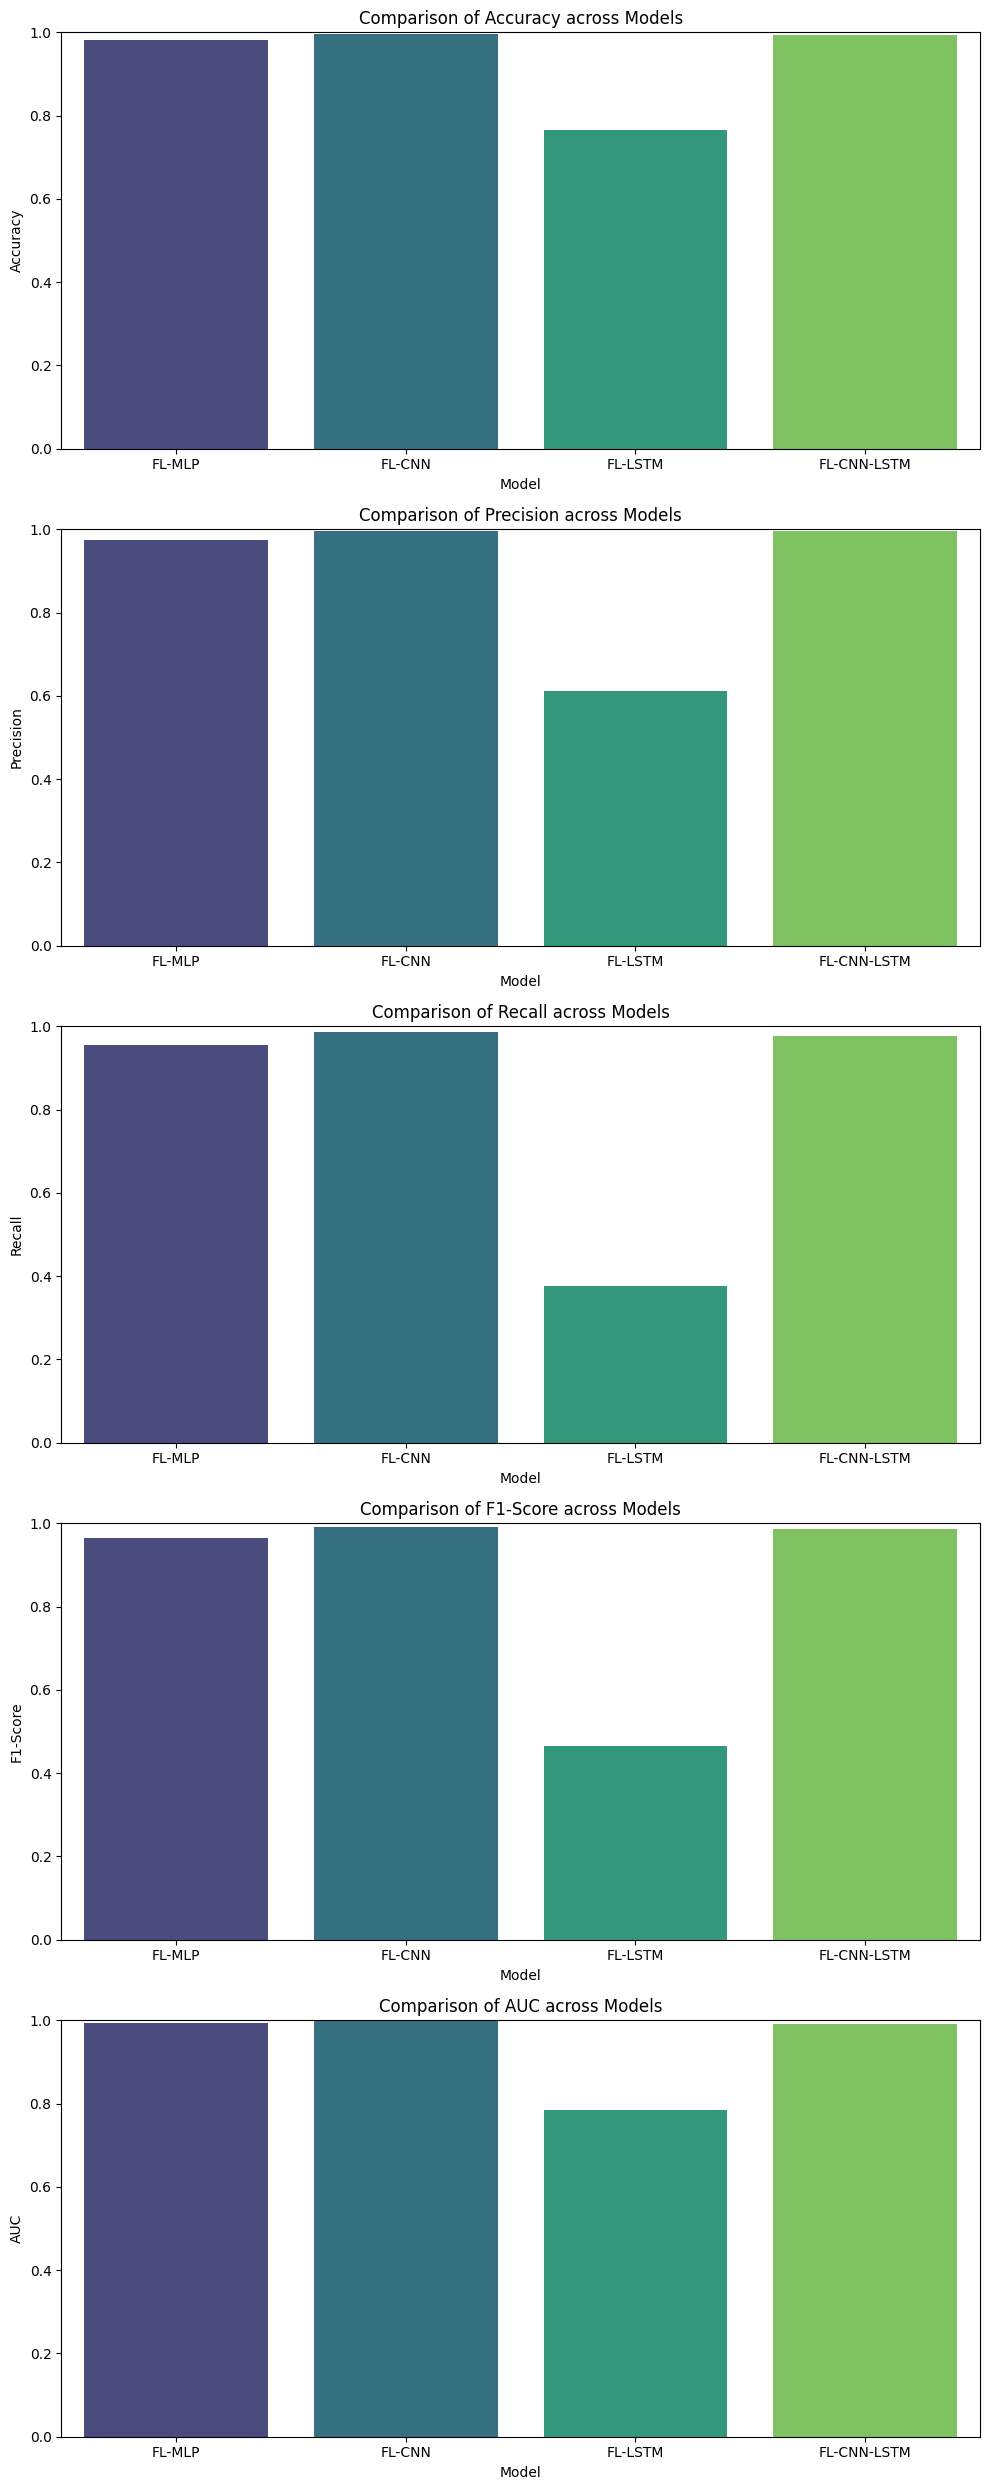

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 5 * len(metrics_to_plot)))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y=metric, data=comparison_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric} across Models')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
comparison_df.to_csv("FL_IDS_Model_Comparison.csv", index=False)

In [ ]:
test_sample1 = np.array([[
    1360,
    185.91665031987455,
    58.80699780589712,
    0,
    196,
    6.38600165185291,
    11960.841074904327,
    14.270272737404516,
    1.0830889939284059,
    9,
    4,
    15,
    11,
    1.6970217071674285,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]])
test_sample2 = np.array([[
    602,
    189.3842080447781,
    13.392765138040357,
    1,
    481,
    43.73503417572529,
    5763.534906310956,
    57.43797264186759,
    0.14244154332397044,
    9,
    3,
    0,
    8,
    0.023823202150925645,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]])


In [ ]:
test_sample_scaled1 = scaler.transform(test_sample1)
test_sample_scaled2 = scaler.transform(test_sample2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
test_sample_reshaped1 = test_sample_scaled1.reshape(
    test_sample_scaled1.shape[0],
    test_sample_scaled1.shape[1],
    1
)

test_sample_reshaped2 = test_sample_scaled2.reshape(
    test_sample_scaled2.shape[0],
    test_sample_scaled2.shape[1],
    1
)

In [ ]:
prediction_prob = global_cnn_lstm_model.predict(test_sample_reshaped1)
prediction_label = int(prediction_prob > 0.5)

print("Prediction Probability:", prediction_prob[0][0])
print("Predicted Label:", prediction_label)

if prediction_label == 1:
    print("🚨 ATTACK DETECTED (Anomalous Traffic)")
else:
    print("✅ NORMAL Traffic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction Probability: 0.6771053
Predicted Label: 1
🚨 ATTACK DETECTED (Anomalous Traffic)


/tmp/ipython-input-2106893121.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction_label = int(prediction_prob > 0.5)


In [ ]:
prediction_prob = global_cnn_lstm_model.predict(test_sample_reshaped2)
prediction_label = int(prediction_prob > 0.5)

print("Prediction Probability:", prediction_prob[0][0])
print("Predicted Label:", prediction_label)

if prediction_label == 1:
    print("🚨 ATTACK DETECTED (Anomalous Traffic)")
else:
    print("✅ NORMAL Traffic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Prediction Probability: 0.0016348999
Predicted Label: 0
✅ NORMAL Traffic


/tmp/ipython-input-2682761462.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction_label = int(prediction_prob > 0.5)


In [ ]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

In [ ]:
class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.Wq = self.add_weight(
            name="Wq",
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )
        self.Wk = self.add_weight(
            name="Wk",
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )
        self.Wv = self.add_weight(
            name="Wv",
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )
        super(SelfAttention, self).build(input_shape)

    def call(self, inputs):
        Q = K.dot(inputs, self.Wq)
        K_ = K.dot(inputs, self.Wk)
        V = K.dot(inputs, self.Wv)

        attention_scores = K.batch_dot(Q, K_, axes=[2, 2])
        attention_scores = attention_scores / K.sqrt(
            K.cast(K.shape(K_)[-1], dtype="float32")
        )

        attention_weights = K.softmax(attention_scores)
        output = K.batch_dot(attention_weights, V)

        return output


In [ ]:
def build_cnn_lstm_attention(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),

        Conv1D(128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),

        LSTM(64, return_sequences=True),
        SelfAttention(),

        LSTM(32),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
attention_input_shape = X_train_cnn_lstm.shape[1:]

global_attention_model = build_cnn_lstm_attention(attention_input_shape)
global_attention_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 3, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 3, 64)          │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,105 (387.13 KB)

 Trainable params: 99,105 (387.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def local_train_attention(model, X, y, epochs=5, batch_size=32):
    model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )
    return model.get_weights()

In [ ]:
ROUNDS = 5
LOCAL_EPOCHS = 5

for round_num in range(ROUNDS):
    print("\n==============================")
    print(f" Federated Round {round_num+1} (CNN-LSTM-ATTENTION)")
    print("==============================")

    local_weights = []

    for client, (X_client, y_client) in cnn_lstm_clients.items():
        print(f"\n🔹 Training on {client}")

        local_model = build_cnn_lstm_attention(attention_input_shape)
        local_model.set_weights(global_attention_model.get_weights())

        weights = local_train_attention(
            local_model,
            X_client,
            y_client,
            epochs=LOCAL_EPOCHS
        )

        local_weights.append(weights)
    global_attention_model.set_weights(federated_average(local_weights))


 Federated Round 1 (CNN-LSTM-ATTENTION)

🔹 Training on client_1
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.7521 - loss: 0.6268 - val_accuracy: 0.7312 - val_loss: 0.5798
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7660 - loss: 0.5501 - val_accuracy: 0.7312 - val_loss: 0.5750
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7504 - loss: 0.5695 - val_accuracy: 0.7312 - val_loss: 0.5666
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7432 - loss: 0.5666 - val_accuracy: 0.7312 - val_loss: 0.5404
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7236 - loss: 0.5579 - val_accuracy: 0.7188 - val_loss: 0.4606

🔹 Training on client_2
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7143 - loss: 0.6429 - val_accuracy: 0.7500 - val_loss: 0.5645
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7353 - loss: 0.5778 - val_accuracy: 0.7500 - val_loss: 0.5630
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7359 - loss: 0.5544 - val_accuracy: 0.71

In [ ]:
y_prob_attention = global_attention_model.predict(X_test_cnn_lstm).ravel()
y_pred_attention = (y_prob_attention > 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score

print("CNN-LSTM-Attention Classification Report\n")
print(classification_report(y_test, y_pred_attention))

auc_attention = roc_auc_score(y_test, y_prob_attention)
print("CNN-LSTM-Attention AUC:", auc_attention)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
CNN-LSTM-Attention Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       729
           1       0.97      0.98      0.98       271

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.98      1000
weighted avg       0.99      0.99      0.99      1000

CNN-LSTM-Attention AUC: 0.9941333981241047


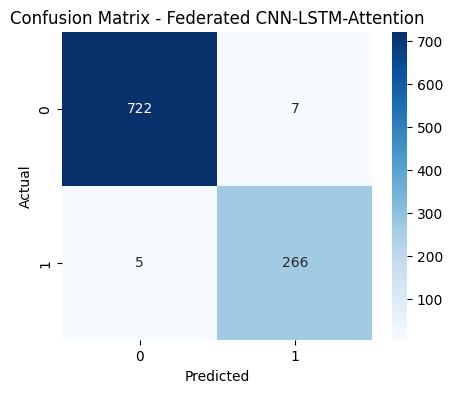

In [ ]:
cm_attention = confusion_matrix(y_test, y_pred_attention)

plt.figure(figsize=(5,4))
sns.heatmap(cm_attention, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Federated CNN-LSTM-Attention")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()